In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.geo import add_geo_features
from pathlib import Path

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("data/raw/nekretnine_dataset.csv")

df.head()

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37 m²,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83 m²,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63 m²,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61 m²,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73 m²,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


In [3]:
print(df.shape)

(9619, 10)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9619 entries, 0 to 9618
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price_EUR         9576 non-null   float64
 1   Square_footage    9603 non-null   str    
 2   Number_of_rooms   9492 non-null   float64
 3   State             9457 non-null   str    
 4   Lift              9619 non-null   int64  
 5   Heating           8829 non-null   str    
 6   Optical_internet  9619 non-null   int64  
 7   Parking           9619 non-null   int64  
 8   Floor             9619 non-null   str    
 9   Street            9619 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 751.6 KB


In [5]:
df.describe()

,Price_EUR,Number_of_rooms,Lift,Optical_internet,Parking
count,9.576000e+03,9492.000000,9619.000000,9619.000000,9619.000000
mean,2.272177e+07,2.937105,0.522300,0.065599,0.291298
std,1.653631e+09,1.213160,0.499528,0.247593,0.454384
min,1.000000e+03,-3.000000,0.000000,0.000000,0.000000
25%,1.499648e+05,2.000000,0.000000,0.000000,0.000000
50%,2.295000e+05,3.000000,1.000000,0.000000,0.000000
75%,3.426528e+05,4.000000,1.000000,0.000000,1.000000
max,1.470304e+11,44.000000,1.000000,1.000000,1.000000


In [6]:
# square footage cleanup
df["Square_footage"] = (
    df["Square_footage"]
    .str.replace(" m²", "", regex=False)
    .astype(float)
)

In [7]:
df.head()

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37.0,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83.0,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63.0,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61.0,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73.0,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


In [8]:
df.isnull().sum()

Price_EUR            43
Square_footage       16
Number_of_rooms     127
State               162
Lift                  0
Heating             790
Optical_internet      0
Parking               0
Floor                 0
Street                0
dtype: int64

In [9]:
#remove missing price 
df = df.dropna(subset=["Price_EUR"])
#remove missing sqaure_footage
df = df.dropna(subset=["Square_footage"])

In [10]:
# fill missing state values
df["State"] = df["State"].fillna("Standardna gradnja")

In [11]:
#fill missing heating values
df["Heating"] = df["Heating"].fillna("Centralno grejanje")

In [12]:
median_m2_per_room = (df["Square_footage"] / df["Number_of_rooms"]).median()
print(median_m2_per_room)

#fill missing room numbers with rounded value of square footage and median of m^2 per room
df.loc[df["Number_of_rooms"].isnull(), "Number_of_rooms"] = (
    df["Square_footage"] / median_m2_per_room
).round()

26.5


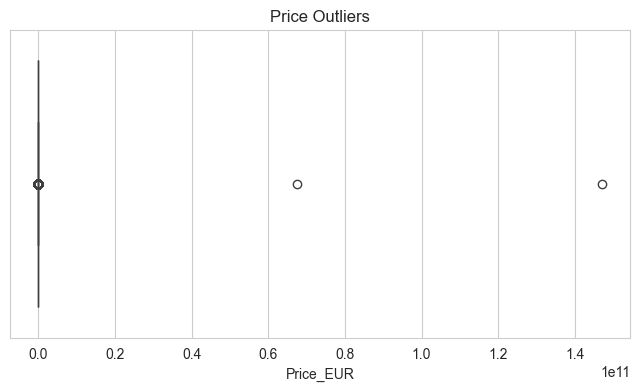

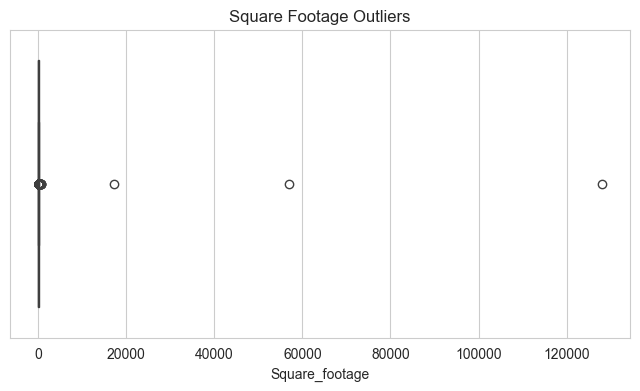

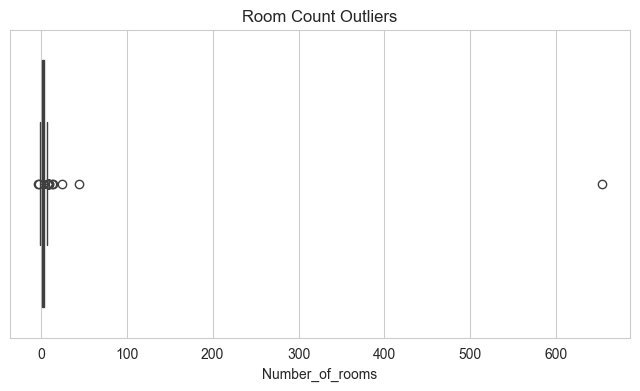

In [13]:
#Checking outliers 
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Price_EUR"])
plt.title("Price Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Square_footage"])
plt.title("Square Footage Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Number_of_rooms"])
plt.title("Room Count Outliers")
plt.show()

In [14]:
df.sort_values("Price_EUR", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
7811,1.470304e+11,125.00,5.0,U izgradnji,1,Centralno grejanje,1,1,7,Vukov spomenik
8422,6.760032e+10,65.29,2.0,U izgradnji,1,Etažno grejanje na gas,0,0,1,Čukarica
7546,4.250450e+07,46.35,2.0,Novogradnja,1,Centralno grejanje,1,1,0,Savski venac
6510,2.023312e+07,49.05,2.0,U izgradnji,1,Centralno grejanje,0,0,4,Voždovac
8936,7.834992e+06,215.84,5.0,Novogradnja,0,Centralno grejanje,0,0,9,Tošin bunar
7438,5.000000e+06,453.19,5.0,Novogradnja,1,"Centralno grejanje, Klima uređaj",0,1,39,Novi Beograd Blok 65
8932,4.234782e+06,118.29,4.0,Novogradnja,0,Centralno grejanje,0,0,10,Tošin bunar
8912,4.122756e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,6,Tošin bunar
8900,4.063521e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,5,Tošin bunar
8913,4.004286e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,4,Tošin bunar


In [15]:
df.sort_values("Square_footage", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
8538,455000.0,128000.00,5.0,Delimična rekonstrukcija,1,Centralno grejanje,0,0,2,Bežanijska kosa II
1967,205000.0,57000.00,3.0,Lux,0,"Podno grejanje, Kamin",0,1,Prizemlje,Zemun (Gardoš)
9414,2250000.0,17300.00,653.0,Standardna gradnja,0,Ostalo,0,0,0,Galenika
9136,800000.0,650.00,25.0,Novogradnja,0,Etažno grejanje na struju,0,1,Prizemlje,Sopot
133,1500000.0,630.00,4.0,Novogradnja,1,Centralno grejanje,1,1,3,Dedinje (RTV Pink)
9039,285000.0,607.00,6.0,Standardna gradnja,0,Ostalo,0,0,2,Barajevo
9574,1400000.0,541.00,8.0,Standardna gradnja,0,"Klima uređaj, Ostalo",0,0,2,Dedinje (RTV Pink)
7438,5000000.0,453.19,5.0,Novogradnja,1,"Centralno grejanje, Klima uređaj",0,1,39,Novi Beograd Blok 65
9600,970000.0,450.00,5.0,Standardna gradnja,0,"Centralno grejanje, Klima uređaj",0,1,7,Vračar (Centar)
5913,600000.0,420.00,2.0,Standardna gradnja,1,Centralno grejanje,0,0,6,Višnjica


In [16]:
df.sort_values("Number_of_rooms", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
9414,2250000.0,17300.0,653.0,Standardna gradnja,0,Ostalo,0,0,0,Galenika
4966,98900.0,44.0,44.0,Lux,0,Etažno grejanje na struju,1,1,Prizemlje,Ledine
9136,800000.0,650.0,25.0,Novogradnja,0,Etažno grejanje na struju,0,1,Prizemlje,Sopot
9522,1100000.0,369.0,14.0,Izvorno stanje,1,"Klima uređaj, Etažno grejanje na struju, Etažn...",1,1,3,Dedinje (Beli dvor)
3864,195000.0,107.0,13.0,Standardna gradnja,0,Etažno grejanje na struju,0,0,1,Banjica
6560,850000.0,310.0,10.0,Standardna gradnja,0,Centralno grejanje,0,0,5,Trg Republike ( centar )
2334,90000.0,62.0,10.0,Standardna gradnja,0,TA peć,0,0,1,Sremčica
3986,1390000.0,205.0,9.0,Standardna gradnja,1,Centralno grejanje,0,0,4,Knez Mihailova ( centar )
5890,491550.0,226.0,9.0,Novogradnja,0,Centralno grejanje,0,0,0,Ledine
4870,990000.0,239.0,9.0,Standardna gradnja,0,"Centralno grejanje, Klima uređaj",0,0,1,Kalemegdan


In [17]:
# droping extreme outliers
df = df[(df["Square_footage"] >= 15) & (df["Square_footage"] <= 400)]
df = df[(df["Number_of_rooms"] > 0) & (df["Number_of_rooms"] <= 10)]

In [18]:
min_price = 20000
max_price = 2000000
df = df[(df["Price_EUR"] >= min_price) & (df["Price_EUR"] <= max_price)]

In [19]:
# Create price per m2 feature
df["price_per_m2"] = df["Price_EUR"] / df["Square_footage"]

# Drop apartments where price_per_m2 > 11,000
df = df[df["price_per_m2"] <= 11000]

# Check the new dataset
print(df.describe())

          Price_EUR  Square_footage  Number_of_rooms         Lift  \
count  9.489000e+03     9489.000000      9489.000000  9489.000000   
mean   2.865833e+05       81.735410         2.918274     0.521973   
std    2.212040e+05       44.905538         1.129634     0.499543   
min    2.100000e+04       15.000000         0.500000     0.000000   
25%    1.500000e+05       53.000000         2.000000     0.000000   
50%    2.295000e+05       70.000000         3.000000     1.000000   
75%    3.400000e+05       98.340000         4.000000     1.000000   
max    2.000000e+06      400.000000        10.000000     1.000000   

       Optical_internet      Parking  price_per_m2  
count       9489.000000  9489.000000   9489.000000  
mean           0.063231     0.289072   3428.187752  
std            0.243391     0.453355   1288.317969  
min            0.000000     0.000000    399.103139  
25%            0.000000     0.000000   2545.454545  
50%            0.000000     0.000000   3250.000000  
75%    

In [20]:
#dropping outliers for small apartments with large amount of rooms
df.loc[df["Square_footage"] < 70, "Number_of_rooms"] = df.loc[df["Square_footage"] < 70, "Number_of_rooms"].clip(upper=4)

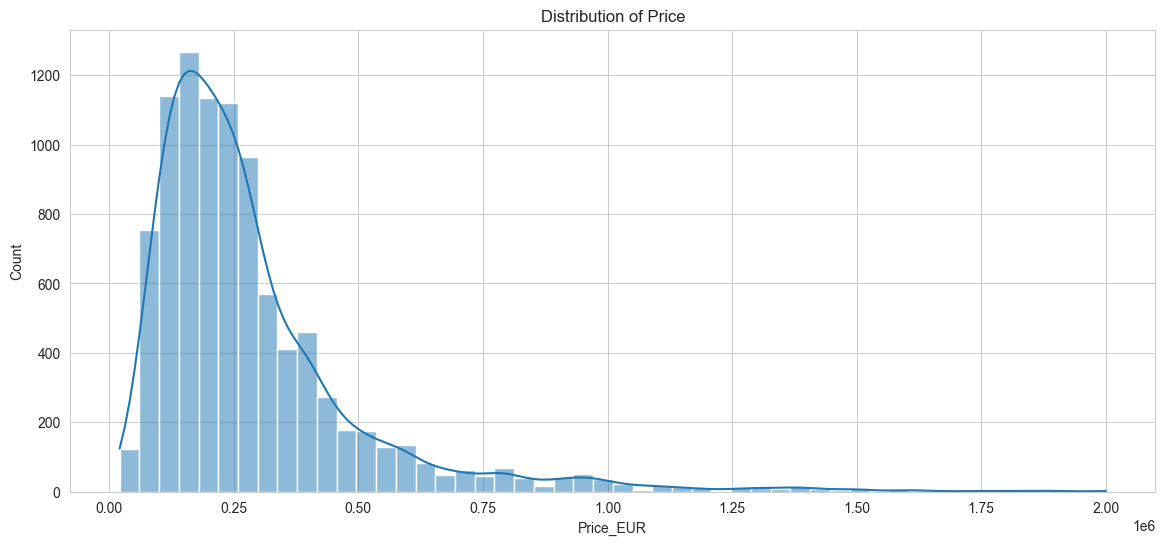

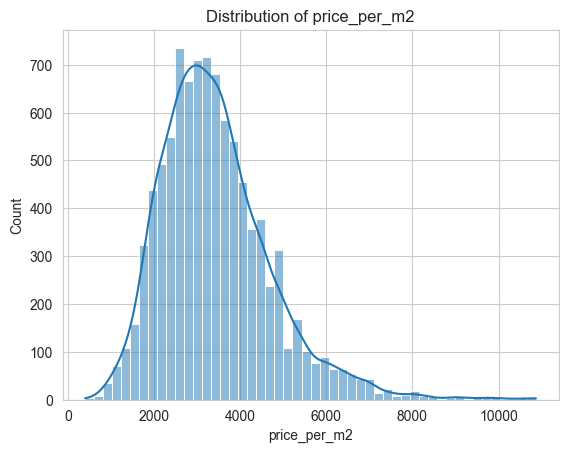

In [21]:
plt.figure(figsize=(14,6))
sns.histplot(df["Price_EUR"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

sns.histplot(df["price_per_m2"], bins=50, kde=True)
plt.title("Distribution of price_per_m2")
plt.show()

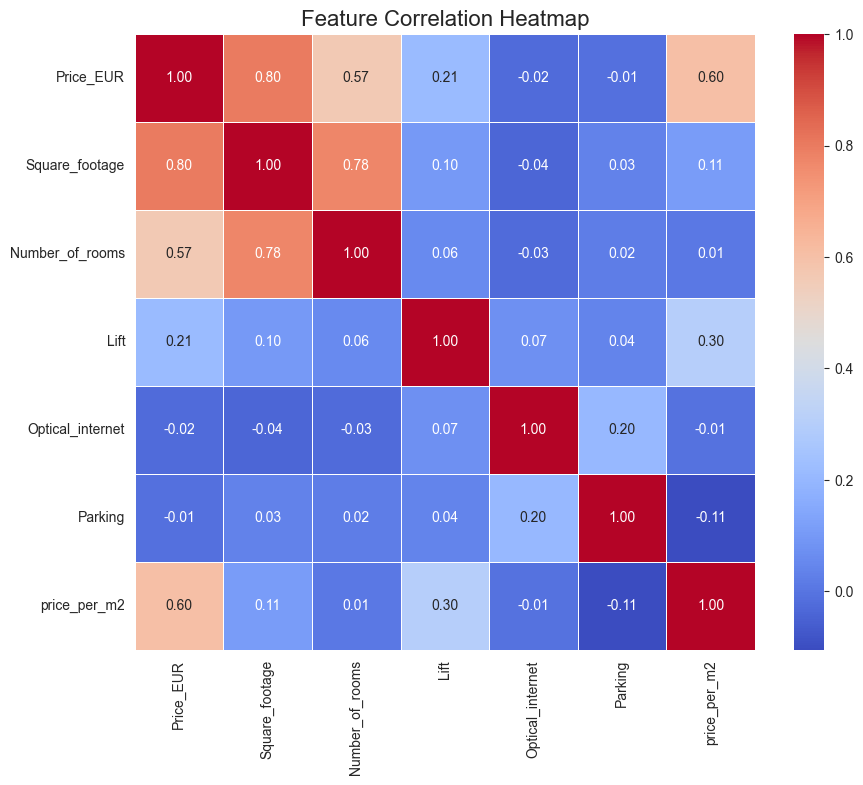

In [22]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

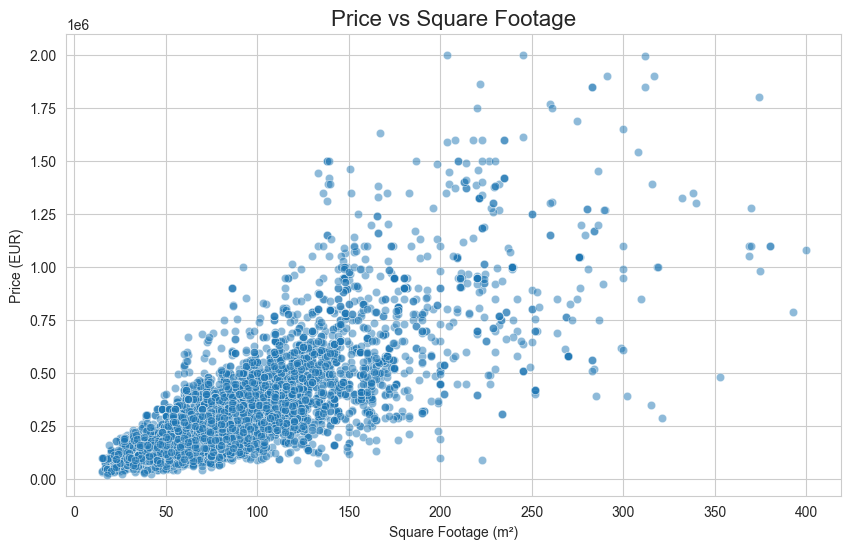

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Square_footage",
    y="Price_EUR",
    data=df,
    alpha=0.5
)

plt.title("Price vs Square Footage", fontsize=16)
plt.xlabel("Square Footage (m²)")
plt.ylabel("Price (EUR)")
plt.show()

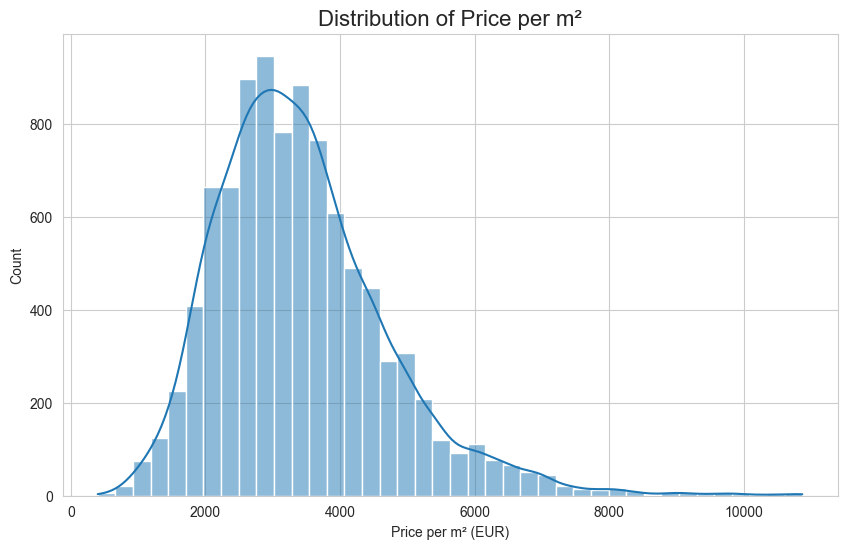

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price_per_m2"],
    bins=40,
    kde=True
)

plt.title("Distribution of Price per m²", fontsize=16)
plt.xlabel("Price per m² (EUR)")
plt.show()

In [25]:
df["State"].unique()

<StringArray>
[      'Standardna gradnja',           'Izvorno stanje',
              'Novogradnja',                      'Lux',
 'Kompletna rekonstrukcija',              'U izgradnji',
       'Završena izgradnja', 'Delimična rekonstrukcija',
               'U pripremi']
Length: 9, dtype: str

In [26]:
df["Heating"].unique()

<StringArray>
[                                                                                                                                   'Centralno grejanje',
                                                                                                                      'Centralno grejanje, Klima uređaj',
                                                                                                                                'Etažno grejanje na gas',
                                                                                                                                                'Ostalo',
                                                                                                                                        'Toplotna pumpa',
                                                                                                               'Klima uređaj, Etažno grejanje na struju',
                                                              

In [27]:
df["Street"].unique()

<StringArray>
[                                  'Žarkovo',
                              'Miljakovac I',
                                 'Karaburma',
                                  'Zvezdara',
                                   'Krnjača',
                               'Medaković I',
                           'Vračar (Centar)',
               'Novi Beograd Blok 12 (YUBC)',
                               'Autokomanda',
                                  'Voždovac',
 ...
                                'Ostružnica',
                              'Medak padina',
                                   'Trešnja',
                             'Gradic Pejton',
                     'Novi Beograd Blok 11b',
                                     'Avala',
                               'Jabučki rit',
                          'Zemun (Sutjeska)',
                                     'Makiš',
 'Novi Beograd Blok 16 (Ušće šoping centar)']
Length: 256, dtype: str

In [28]:
#Categorize the state feature
state_map = {
    "Novogradnja": "New",
    "U izgradnji": "New",
    "Završena izgradnja": "New",
    "U pripremi": "New",

    "Standardna gradnja": "Standard",

    "Izvorno stanje": "Needs_renovation",

    "Kompletna rekonstrukcija": "Renovated",
    "Delimična rekonstrukcija": "Renovated",

    "Lux": "Luxury"
}

df["State"] = df["State"].map(state_map)

In [29]:
# Heating categorization
heating_types = [
    "Centralno grejanje",
    "Etažno grejanje na gas",
    "Etažno grejanje na struju",
    "Etažno grejanje na čvrsto gorivo",
    "Podno grejanje",
    "Toplotna pumpa",
    "TA peć",
    "Kamin",
    "Peć na drva/ugalj",
    "Klima uređaj"
]

for heating in heating_types:
    df[f"heating_{heating}"] = df["Heating"].str.contains(heating, na=False).astype(int)

df.drop(columns=["Heating"], inplace=True)

In [30]:
df = add_geo_features(
    df,
    location_col="Street",
    cache_path=Path("geo_cache.csv"),
    user_agent="belgrade_real_estate_model",
    city_hint="Belgrade",
    country_hint="Serbia",
    delay_seconds=1,
    center_lat=44.8167,
    center_lon=20.4600
)

In [31]:
# fix broken coordinates
df = df[
    (df["lat"].between(44.6, 45.0)) &
    (df["lon"].between(20.2, 20.7))
]

In [32]:
# drop this column since its not neccessary(0 missing after droping)
df = df.drop(columns=["geo_missing"])


<Axes: xlabel='dist_to_center_km', ylabel='Price_EUR'>

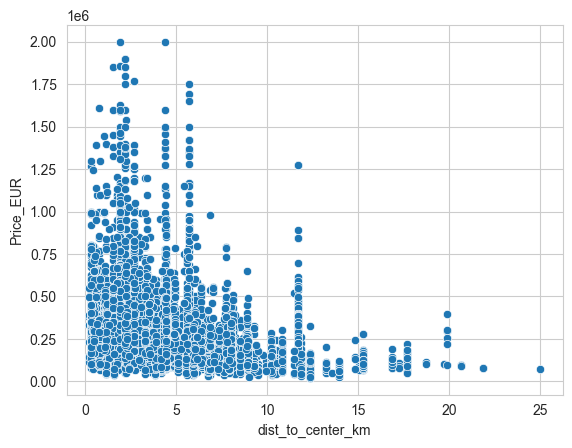

In [33]:
sns.scatterplot(x="dist_to_center_km", y="Price_EUR", data=df)

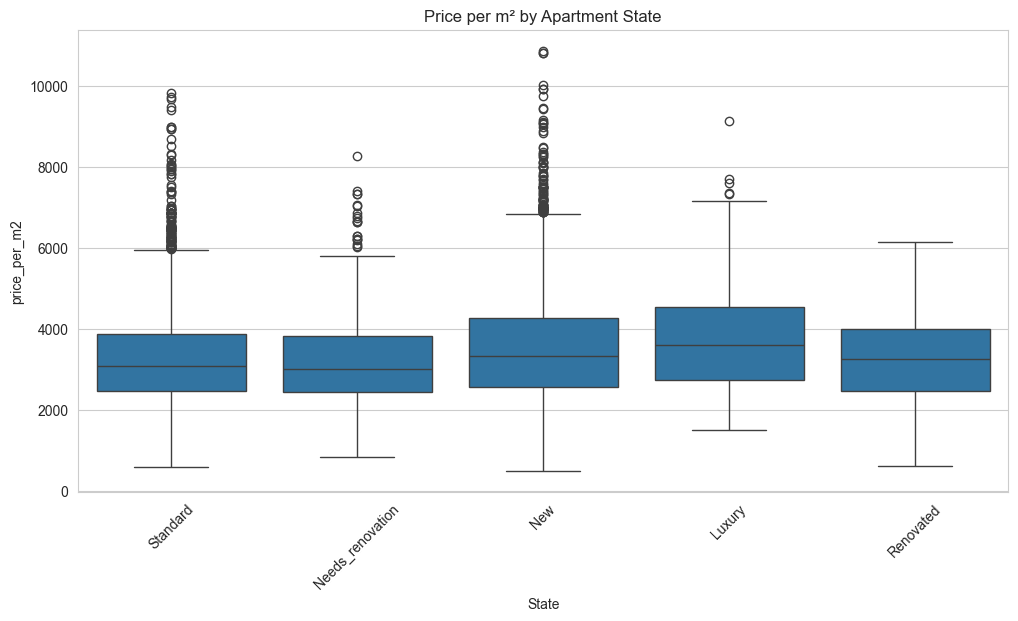

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="State", y="price_per_m2")
plt.xticks(rotation=45)
plt.title("Price per m² by Apartment State")
plt.show()

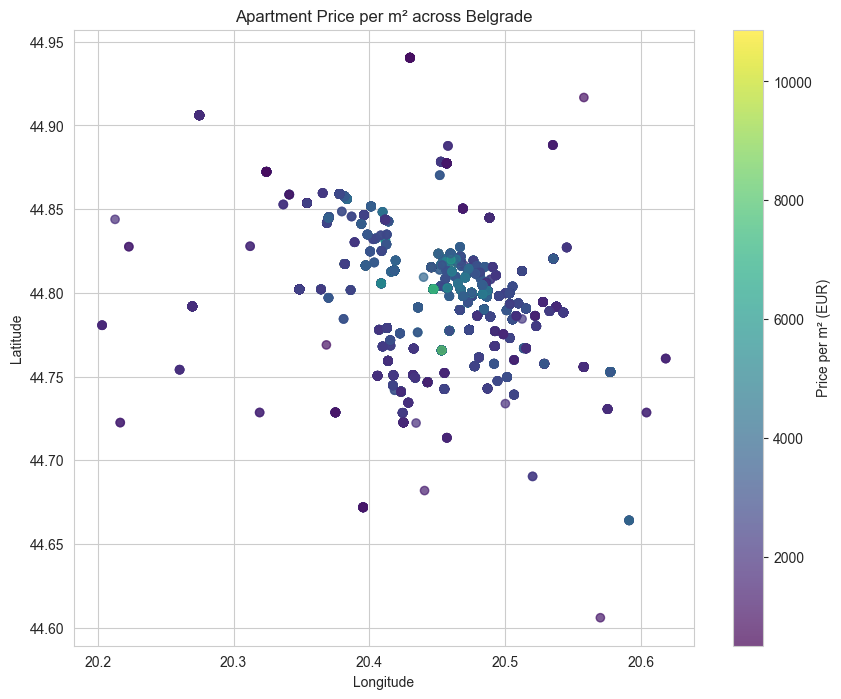

In [35]:

plt.figure(figsize=(10,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["price_per_m2"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Price per m² (EUR)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Apartment Price per m² across Belgrade")

plt.show()

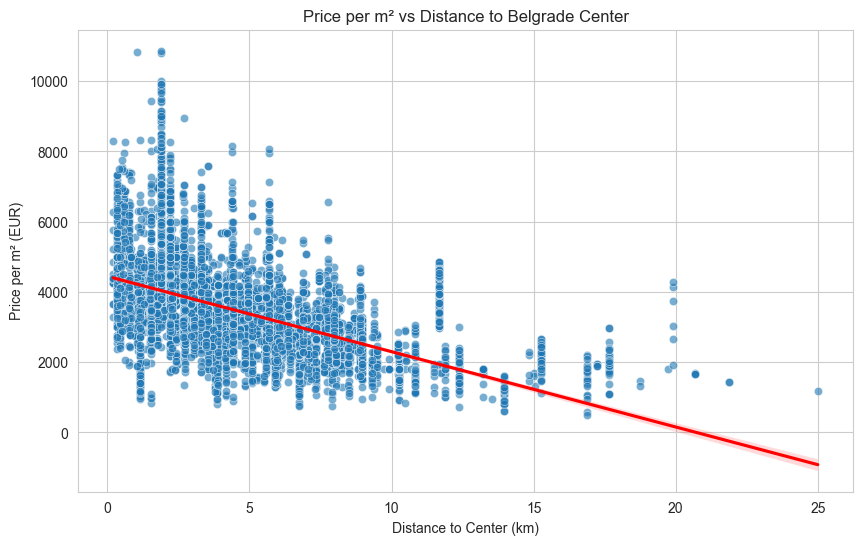

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="dist_to_center_km",
    y="price_per_m2",
    alpha=0.6
)

sns.regplot(
    data=df,
    x="dist_to_center_km",
    y="price_per_m2",
    scatter=False,
    color="red"
)

plt.title("Price per m² vs Distance to Belgrade Center")
plt.xlabel("Distance to Center (km)")
plt.ylabel("Price per m² (EUR)")

plt.show()

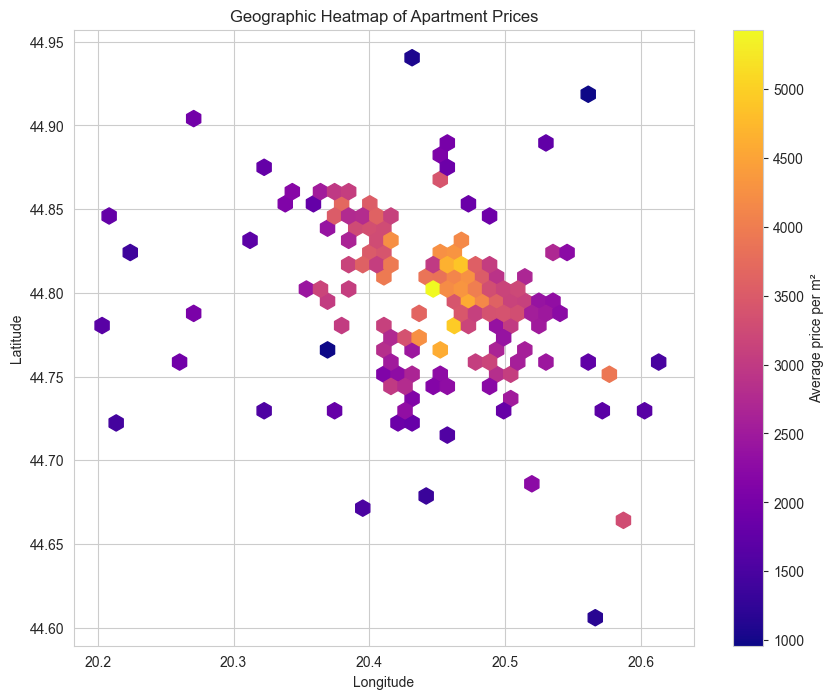

In [37]:
plt.figure(figsize=(10,8))

plt.hexbin(
    df["lon"],
    df["lat"],
    C=df["price_per_m2"],
    gridsize=40,
    cmap="plasma"
)

plt.colorbar(label="Average price per m²")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Heatmap of Apartment Prices")

plt.show()

In [38]:
print(df.columns)

Index(['Price_EUR', 'Square_footage', 'Number_of_rooms', 'State', 'Lift',
       'Optical_internet', 'Parking', 'Floor', 'Street', 'price_per_m2',
       'heating_Centralno grejanje', 'heating_Etažno grejanje na gas',
       'heating_Etažno grejanje na struju',
       'heating_Etažno grejanje na čvrsto gorivo', 'heating_Podno grejanje',
       'heating_Toplotna pumpa', 'heating_TA peć', 'heating_Kamin',
       'heating_Peć na drva/ugalj', 'heating_Klima uređaj', 'lat', 'lon',
       'geo_status', 'dist_to_center_km'],
      dtype='str')


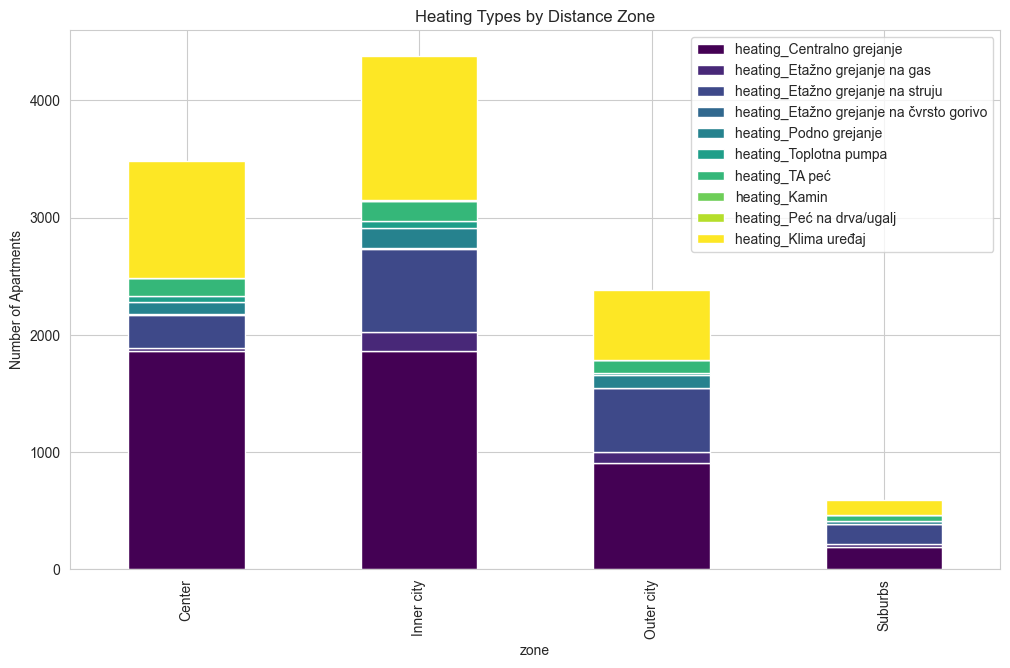

In [39]:
df["zone"] = pd.cut(
    df["dist_to_center_km"],
    bins=[0,3,6,10,25],
    labels=["Center","Inner city","Outer city","Suburbs"]
)

heating_cols = [c for c in df.columns if c.startswith("heating_")]

heating_zone = df.groupby("zone")[heating_cols].sum()

heating_zone.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="viridis"
)

plt.title("Heating Types by Distance Zone")
plt.ylabel("Number of Apartments")

plt.show()

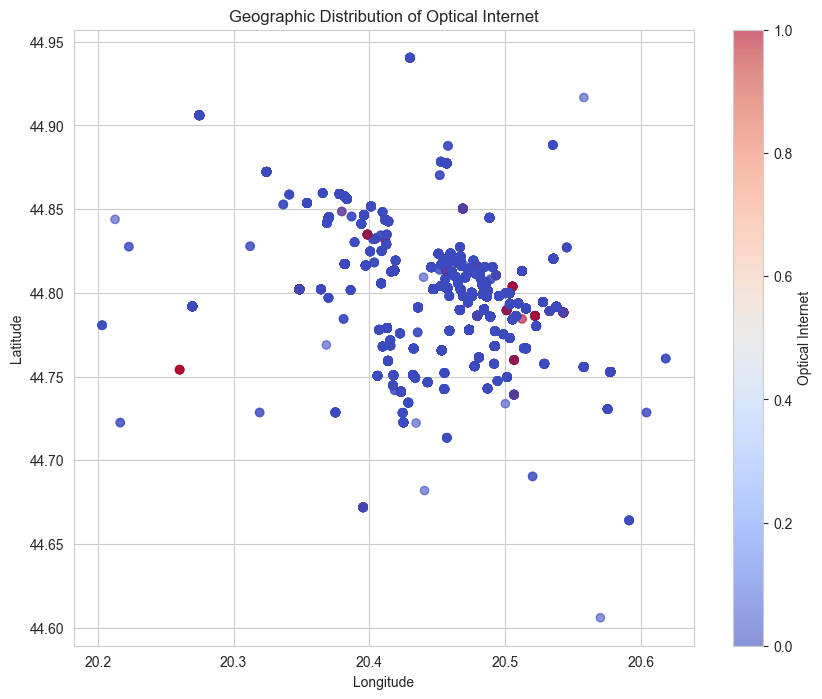

In [40]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["Optical_internet"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="Optical Internet")
plt.title("Geographic Distribution of Optical Internet")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [41]:
print(df[["dist_to_center_km","Optical_internet"]].corr())

                   dist_to_center_km  Optical_internet
dist_to_center_km            1.00000           0.04026
Optical_internet             0.04026           1.00000


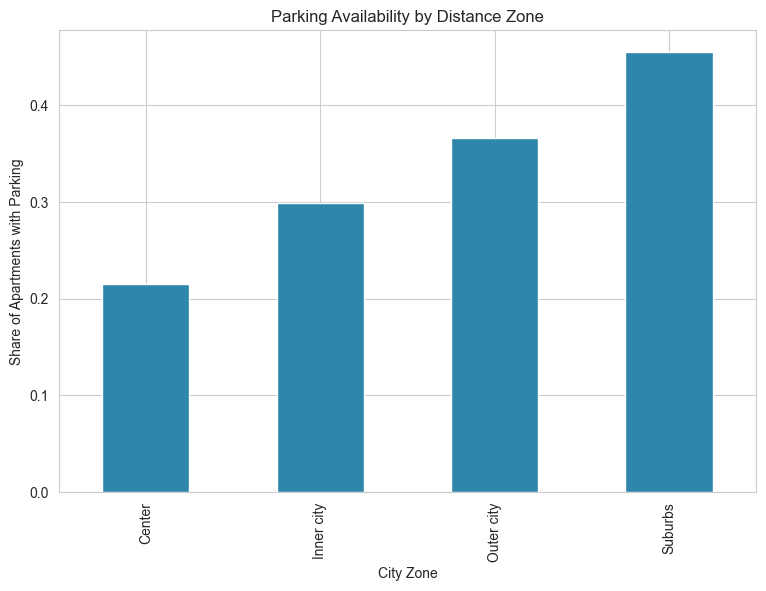

In [42]:
df["zone"] = pd.cut(
    df["dist_to_center_km"],
    bins=[0,3,6,10,25],
    labels=["Center","Inner city","Outer city","Suburbs"]
) 

parking_zone = df.groupby("zone")["Parking"].mean()

plt.figure(figsize=(9,6))

parking_zone.plot(
    kind="bar",
    color="#2E86AB"
)

plt.title("Parking Availability by Distance Zone")
plt.ylabel("Share of Apartments with Parking")
plt.xlabel("City Zone")

plt.show()

C:\Users\Luka Saric\AppData\Local\Temp\ipykernel_4788\1255840651.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


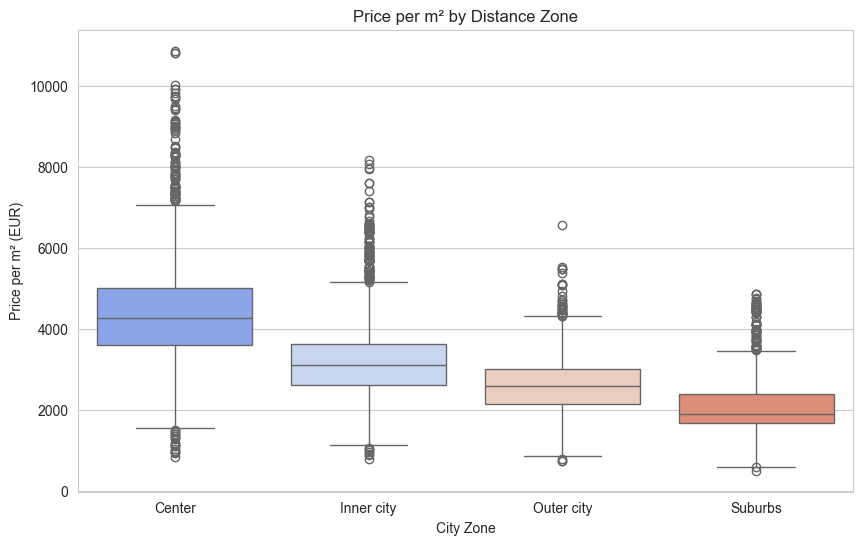

In [43]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="zone",
    y="price_per_m2",
    palette="coolwarm"
)

plt.title("Price per m² by Distance Zone")
plt.ylabel("Price per m² (EUR)")
plt.xlabel("City Zone")

plt.show()

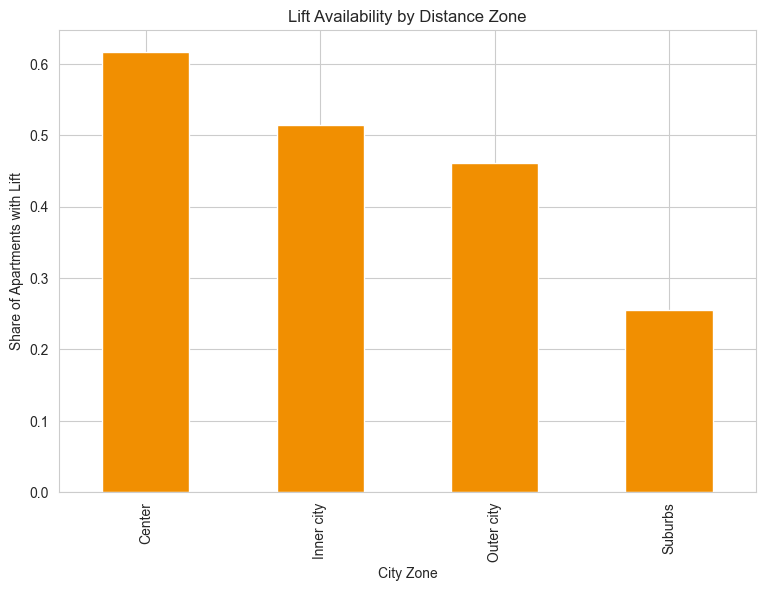

In [44]:
lift_zone = df.groupby("zone")["Lift"].mean()

plt.figure(figsize=(9,6))

lift_zone.plot(
    kind="bar",
    color="#F18F01"
)

plt.title("Lift Availability by Distance Zone")
plt.ylabel("Share of Apartments with Lift")
plt.xlabel("City Zone")

plt.show()

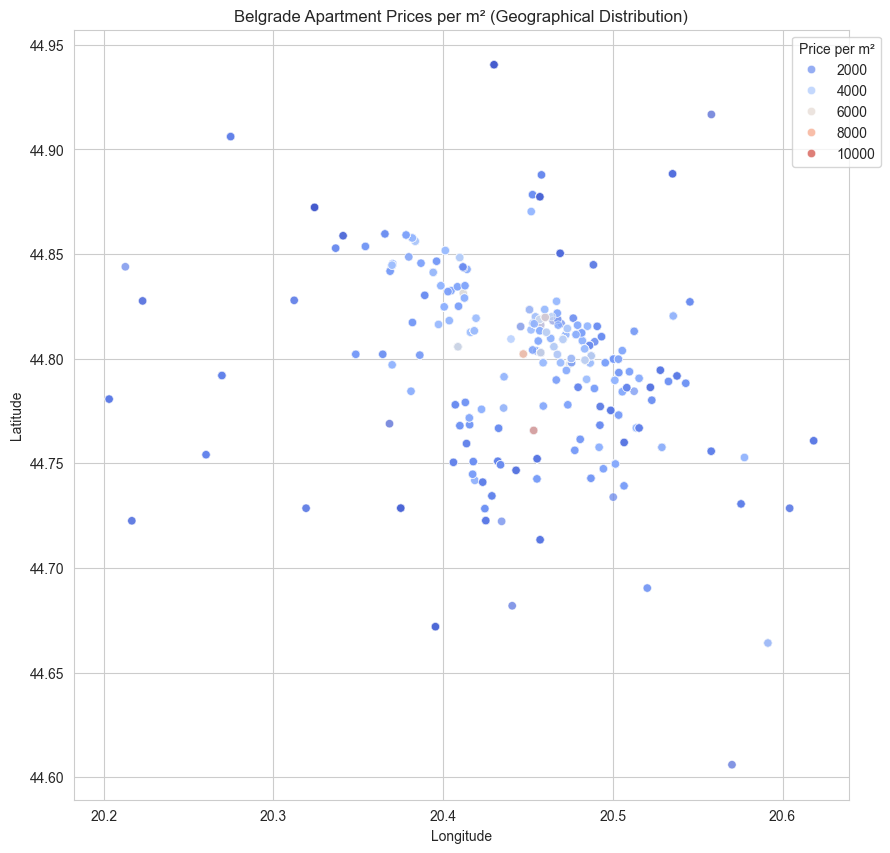

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

sns.scatterplot(
    data=df,
    x="lon",
    y="lat",
    hue="price_per_m2",
    palette="coolwarm",
    alpha=0.7
)

plt.title("Belgrade Apartment Prices per m² (Geographical Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="Price per m²", bbox_to_anchor=(1.05,1))

plt.show()

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 8804 entries, 0 to 9617
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   Price_EUR                                 8804 non-null   float64 
 1   Square_footage                            8804 non-null   float64 
 2   Number_of_rooms                           8804 non-null   float64 
 3   State                                     8804 non-null   str     
 4   Lift                                      8804 non-null   int64   
 5   Optical_internet                          8804 non-null   int64   
 6   Parking                                   8804 non-null   int64   
 7   Floor                                     8804 non-null   str     
 8   Street                                    8804 non-null   str     
 9   price_per_m2                              8804 non-null   float64 
 10  heating_Centralno grejanje              

In [47]:
print(df["Floor"].unique())
# Mapping special floor names to numbers
floor_mapping = {
    "Suteren": -1,
    "Prizemlje": 0,
    "Visoko prizemlje": 0.5
}

# Replace mapped values
df["Floor"] = df["Floor"].replace(floor_mapping)

# Convert the rest to float
df["Floor"] = df["Floor"].astype(float)

<StringArray>
[               '0',                '4',                '3',
                '2',                '1',                '5',
                '7',                '6',                '9',
          'Suteren',        'Prizemlje',               '14',
 'Visoko prizemlje',               '20',               '13',
               '15',               '12',               '10',
                '8',               '23',               '22',
               '19',               '11',               '40',
               '21',               '27',               '30',
               '16',               '18',               '26',
               '24',               '-1',               '17',
               '29',               '28',               '36',
               '34',               '33',               '25']
Length: 39, dtype: str


In [48]:
# 1️⃣ Features and target
X = df.drop(columns=["Price_EUR", "Street", "zone","geo_status","price_per_m2"])
y = df["Price_EUR"]

In [49]:
# 2️⃣ Identify categorical and numerical columns
categorical_cols = ["State"]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# 3️⃣ Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough" , # leave numeric columns as-is
     force_int_remainder_cols=False
)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [55]:
# Linear regression 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Preprocessing: scale numeric features and one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),  # scale numeric
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)  # one-hot encode
    ]
)


lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

Linear Regression -> MAE: 62939.04, RMSE: 97257.01, R2: 0.76


In [68]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"  
)

# Decision Tree pipeline
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("regressor", DecisionTreeRegressor(max_depth=8, random_state=42))
])

# Train the model
dt_pipeline.fit(X_train, y_train)

# Predict
y_pred_dt = dt_pipeline.predict(X_test)

# Evaluate
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree -> MAE: {mae_dt:.2f}, RMSE: {rmse_dt:.2f}, R2: {r2_dt:.2f}")

Decision Tree -> MAE: 50689.87, RMSE: 85744.34, R2: 0.82


In [67]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest -> MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.2f}")

Random Forest -> MAE: 37955.81, RMSE: 73742.95, R2: 0.86


In [71]:
# Random forest optimization
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Hyperparameter grid
param_dist = {
    "regressor__n_estimators": [100, 200, 300, 400],
    "regressor__max_depth": [None, 10, 20, 30, 40],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": [None, "sqrt", "log2"]
}

# Randomized search
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,           # number of random combinations to try
    cv=3,                # 3-fold cross-validation
    scoring="r2",        # optimize for R²
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Run the search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Evaluate best model
y_pred_rf_best = random_search.best_estimator_.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_rf_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_rf_best))
r2_best = r2_score(y_test, y_pred_rf_best)

print(f"Optimized Random Forest -> MAE: {mae_best:.2f}, RMSE: {rmse_best:.2f}, R2: {r2_best:.2f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': None, 'regressor__max_depth': None}
Optimized Random Forest -> MAE: 37921.43, RMSE: 73453.68, R2: 0.86


In [72]:
# XGBoost 
from xgboost import XGBRegressor

# Preprocessor (same as before)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_pipeline.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost -> MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R2: {r2_xgb:.2f}")

XGBoost -> MAE: 39242.37, RMSE: 74214.88, R2: 0.86


In [74]:
# xgboost optimization

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("regressor", XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

# Enhanced hyperparameter grid
param_dist = {
    "regressor__n_estimators": [200, 300, 400, 500, 600],
    "regressor__max_depth": [4, 5, 6, 7, 8, 10],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1, 0.2],
    "regressor__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__gamma": [0, 0.1, 0.2, 0.3],
    "regressor__reg_alpha": [0, 0.01, 0.1, 1],
    "regressor__reg_lambda": [1, 1.5, 2, 3]
}

# Randomized search
random_search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50,          
    cv=3,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Run search
random_search_xgb.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search_xgb.best_params_)

# Evaluate best model
y_pred_xgb_best = random_search_xgb.best_estimator_.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_xgb_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_xgb_best))
r2_best = r2_score(y_test, y_pred_xgb_best)

print(f"Optimized XGBoost -> MAE: {mae_best:.2f}, RMSE: {rmse_best:.2f}, R2: {r2_best:.2f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'regressor__subsample': 0.7, 'regressor__reg_lambda': 1, 'regressor__reg_alpha': 0, 'regressor__n_estimators': 500, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.03, 'regressor__gamma': 0.2, 'regressor__colsample_bytree': 0.9}
Optimized XGBoost -> MAE: 40293.00, RMSE: 74006.15, R2: 0.86
